In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv("marketing_campaign_dataset.csv")

# Phase 1- Data Loading & Initial Exploration

In [3]:
df.head()
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Campaign_ID       200000 non-null  int64  
 1   Company           200000 non-null  str    
 2   Campaign_Type     200000 non-null  str    
 3   Target_Audience   200000 non-null  str    
 4   Duration          200000 non-null  str    
 5   Channel_Used      200000 non-null  str    
 6   Conversion_Rate   200000 non-null  float64
 7   Acquisition_Cost  200000 non-null  str    
 8   ROI               200000 non-null  float64
 9   Location          200000 non-null  str    
 10  Language          200000 non-null  str    
 11  Clicks            200000 non-null  int64  
 12  Impressions       200000 non-null  int64  
 13  Engagement_Score  200000 non-null  int64  
 14  Customer_Segment  200000 non-null  str    
 15  Date              200000 non-null  str    
dtypes: float64(2), int64(4), str(10

**Note:** 
1- We see that acquisition_cost is listed as a string. We have to convert it into a number.
2- The column names have capital letters; it is recommended to unify them to lowercase.  

In [4]:
df.columns = df.columns.str.strip().str.lower().str.replace(' ', '_')

In [5]:
print(df['acquisition_cost'].head(10).tolist())

['$16,174.00', '$11,566.00', '$10,200.00', '$12,724.00', '$16,452.00', '$9,716.00', '$11,067.00', '$13,280.00', '$18,066.00', '$13,766.00']


**Note:** We have to remove the dollar sign "$", and the thousands separator ",".

In [6]:
df['acquisition_cost'] = (
    df['acquisition_cost']
    .astype(str)
    .str.replace('$', '', regex=False)   # remove dollar sign
    .str.replace(',', '', regex=False)   # remove thousands separator
)

df['acquisition_cost'] = pd.to_numeric(df['acquisition_cost'], errors='coerce')



**Validate** 

In [7]:
df['acquisition_cost'].head()
df['acquisition_cost'].notna().sum()


np.int64(200000)

In [8]:
df.head()
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   campaign_id       200000 non-null  int64  
 1   company           200000 non-null  str    
 2   campaign_type     200000 non-null  str    
 3   target_audience   200000 non-null  str    
 4   duration          200000 non-null  str    
 5   channel_used      200000 non-null  str    
 6   conversion_rate   200000 non-null  float64
 7   acquisition_cost  200000 non-null  float64
 8   roi               200000 non-null  float64
 9   location          200000 non-null  str    
 10  language          200000 non-null  str    
 11  clicks            200000 non-null  int64  
 12  impressions       200000 non-null  int64  
 13  engagement_score  200000 non-null  int64  
 14  customer_segment  200000 non-null  str    
 15  date              200000 non-null  str    
dtypes: float64(3), int64(4), str(9)

## **Step 1- Basic Cleaning**

### 1- Convert Date column

In [9]:
df['date'] = pd.to_datetime(df['date'], format="%d/%m/%Y")


### 2- Check Missing Values

In [10]:
df.isnull().sum()


campaign_id         0
company             0
campaign_type       0
target_audience     0
duration            0
channel_used        0
conversion_rate     0
acquisition_cost    0
roi                 0
location            0
language            0
clicks              0
impressions         0
engagement_score    0
customer_segment    0
date                0
dtype: int64

*No Missing Values*

### 4- Remove duplicates

In [11]:
df = df.drop_duplicates()


## **Step 2: Quick Data Understanding**

### Numerical summary

In [12]:
df.describe()


,campaign_id,conversion_rate,acquisition_cost,roi,clicks,impressions,engagement_score,date
count,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000.000000,200000
mean,100000.500000,0.080070,12504.393040,5.002438,549.772030,5507.301520,5.494710,2021-07-01 23:35:09.600000
min,1.000000,0.010000,5000.000000,2.000000,100.000000,1000.000000,1.000000,2021-01-01 00:00:00
25%,50000.750000,0.050000,8739.750000,3.500000,325.000000,3266.000000,3.000000,2021-04-02 00:00:00
50%,100000.500000,0.080000,12496.500000,5.010000,550.000000,5517.500000,5.000000,2021-07-02 00:00:00
75%,150000.250000,0.120000,16264.000000,6.510000,775.000000,7753.000000,8.000000,2021-10-01 00:00:00
max,200000.000000,0.150000,20000.000000,8.000000,1000.000000,10000.000000,10.000000,2021-12-31 00:00:00
std,57735.171256,0.040602,4337.664545,1.734488,260.019056,2596.864286,2.872581,NaN


### Categorical overview

In [13]:
df['channel_used'].value_counts()
df['campaign_type'].value_counts()

campaign_type
Influencer      40169
Search          40157
Display         39987
Email           39870
Social Media    39817
Name: count, dtype: int64

## Step 3: Sanity Checks

### 1- Check ranges

In [14]:
df['conversion_rate'].min(), df['conversion_rate'].max()

(np.float64(0.01), np.float64(0.15))

*Conversion rate (min, max) is logical. <1*

In [15]:
df['roi'].min(), df['roi'].max()

(np.float64(2.0), np.float64(8.0))

*ROI (min, max) is logical. Not negative or extreme.*

### 2- Check zero/impossible values

In [16]:
(df['clicks'] > df['impressions']).sum()

np.int64(0)

*There are 0 rows where clicks > impressions*

## Step 4: Quick Visual Exploration

### 1- Distribution of key metrics:

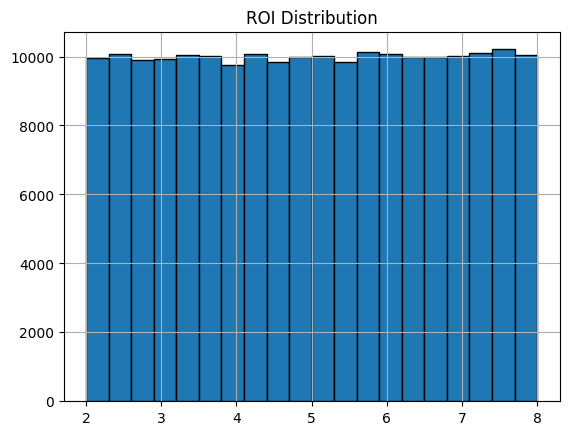

In [17]:
df['roi'].hist(bins=20, edgecolor='black')
plt.title("ROI Distribution")
plt.show()


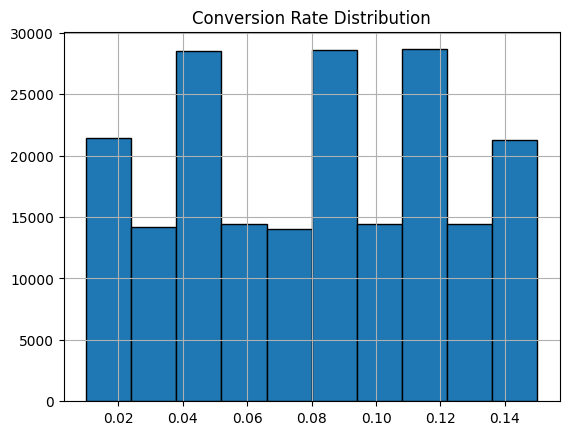

In [18]:
df['conversion_rate'].hist(bins=10, edgecolor='black')
plt.title("Conversion Rate Distribution")
plt.show()


### 2- Channel performance (Quick view)

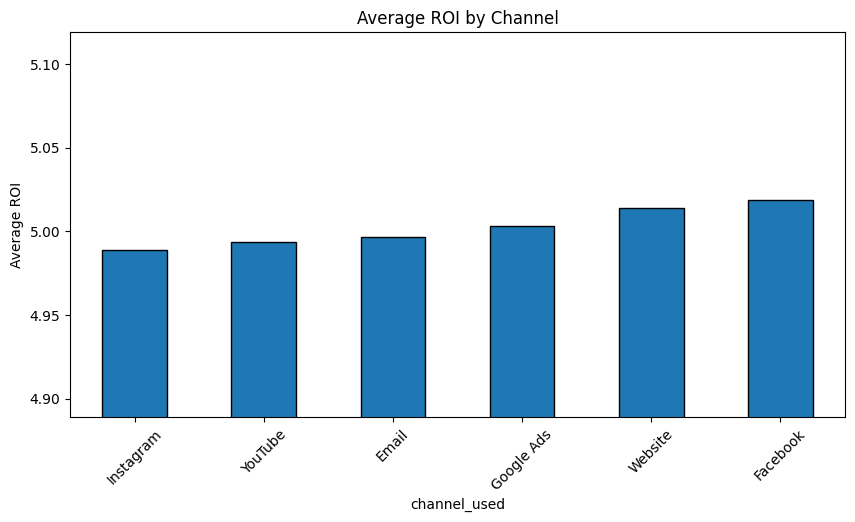

In [19]:
import matplotlib.pyplot as plt

roi_by_channel = df.groupby('channel_used')['roi'].mean().sort_values()

plt.figure(figsize=(10,5))
roi_by_channel.plot(kind='bar', edgecolor='black')

plt.title("Average ROI by Channel")
plt.ylabel("Average ROI")

# Zoom y-axis tightly around data
plt.ylim(roi_by_channel.min() * 0.98, roi_by_channel.max() * 1.02)

plt.xticks(rotation=45)
plt.show()



# Phase 2- Feature Engineering

## Step 1: Core Marketing Metrics

**Important Assumption:** “Conversions, cost, and revenue were derived using standard marketing assumptions due to dataset limitations.”

### 1- CTR (Click Through Rate)

In [20]:
df['ctr'] = df['clicks'] / df['impressions']


### 2- Conversion (Estimated)

In [21]:
df['conversions'] = df['clicks'] * df['conversion_rate']

### 3- Total Cost

**Assumption:** 👉 acquisition_cost = cost per conversion

In [22]:
df['total_cost'] = df['conversions'] * df['acquisition_cost']

### 4- Revenue (Derived for ROI)

ROI = (Revenue - Cost) / Cost

In [23]:
df['revenue'] = df['total_cost'] * (1 + df['roi'])

### 5- Profit

In [24]:
df['profit'] = df['revenue'] - df['total_cost']

## Step 2: Validating the new Metrics

**Distributions:**

In [25]:
df[['ctr', 'conversions', 'total_cost', 'revenue', 'profit']].describe()

,ctr,conversions,total_cost,revenue,profit
count,200000.000000,200000.000000,2.000000e+05,2.000000e+05,2.000000e+05
mean,0.140405,44.022898,5.504431e+05,3.304546e+06,2.754103e+06
std,0.130881,32.317026,4.680032e+05,3.077718e+06,2.656932e+06
min,0.010054,1.000000,5.338860e+03,2.353446e+04,1.603941e+04
25%,0.058606,17.760000,1.979460e+05,1.098199e+06,8.792916e+05
50%,0.099789,35.760000,4.102331e+05,2.330441e+06,1.891944e+06
75%,0.169699,64.100000,7.695080e+05,4.515362e+06,3.734819e+06
max,0.992024,150.000000,2.928787e+06,2.532156e+07,2.245388e+07


**Sanity checks:**

In [26]:
(df['ctr'] > 1).sum()  # should be 0

np.int64(0)

In [27]:
(df['conversions'] > df['clicks']).sum()  # should be 0

np.int64(0)

**Look at outliers:**

In [28]:
df.sort_values('roi', ascending=False).head()
df.sort_values('profit', ascending=False).head()

,campaign_id,company,campaign_type,target_audience,duration,channel_used,conversion_rate,acquisition_cost,roi,location,...,clicks,impressions,engagement_score,customer_segment,date,ctr,conversions,total_cost,revenue,profit
77430,77431,DataTech Solutions,Email,Men 25-34,30 days,YouTube,0.15,19272.0,7.83,New York,...,992,7215,7,Fashionistas,2021-02-20,0.137491,148.80,2867673.60,2.532156e+07,2.245388e+07
118703,118704,Alpha Innovations,Social Media,Women 25-34,30 days,Instagram,0.15,19582.0,7.75,Miami,...,967,4740,6,Foodies,2021-03-20,0.204008,145.05,2840369.10,2.485323e+07,2.201286e+07
91969,91970,DataTech Solutions,Display,Women 35-44,15 days,Facebook,0.14,19972.0,7.92,Miami,...,984,8564,1,Fashionistas,2021-12-21,0.114900,137.76,2751342.72,2.454198e+07,2.179063e+07
72974,72975,DataTech Solutions,Search,Women 35-44,30 days,YouTube,0.15,19605.0,7.81,Chicago,...,936,6781,4,Health & Wellness,2021-12-06,0.138033,140.40,2752542.00,2.424990e+07,2.149735e+07
78140,78141,Alpha Innovations,Search,Women 35-44,30 days,Facebook,0.15,19994.0,7.69,Chicago,...,925,2194,3,Tech Enthusiasts,2021-01-31,0.421604,138.75,2774167.50,2.410752e+07,2.133335e+07


## Step 3: First Real Insights (Quick Wins)

### 1- Best Channels by ROI

In [29]:
df.groupby('channel_used')['roi'].mean().sort_values(ascending=False)

channel_used
Facebook      5.018699
Website       5.014167
Google Ads    5.003141
Email         4.996487
YouTube       4.993754
Instagram     4.988706
Name: roi, dtype: float64

### 2- Most Profitable Channels

In [30]:
df.groupby('channel_used')['profit'].sum().sort_values(ascending=False)

channel_used
Email         9.284606e+10
Website       9.237063e+10
Google Ads    9.190433e+10
YouTube       9.138424e+10
Instagram     9.120640e+10
Facebook      9.110890e+10
Name: profit, dtype: float64

### 3- Campaign Efficiency

In [31]:
df.groupby('campaign_type')[['roi', 'ctr', 'conversion_rate']].mean()

,roi,ctr,conversion_rate
campaign_type,,,
Display,5.006551,0.141265,0.080089
Email,4.994295,0.139489,0.079788
Influencer,5.011068,0.140300,0.080315
Search,5.008357,0.139936,0.080021
Social Media,4.991784,0.141041,0.080135


## Insights

### 1- Low CTR but High ROI (Hidden Gems)

*Is there low CTR but high ROI?*

In [32]:
df[(df['ctr'] < df['ctr'].median()) & (df['roi'] > df['roi'].median())]

,campaign_id,company,campaign_type,target_audience,duration,channel_used,conversion_rate,acquisition_cost,roi,location,...,clicks,impressions,engagement_score,customer_segment,date,ctr,conversions,total_cost,revenue,profit
1,2,NexGen Systems,Email,Women 35-44,60 days,Google Ads,0.12,11566.0,5.61,New York,...,116,7523,7,Fashionistas,2021-01-02,0.015419,13.92,160998.72,1.064202e+06,9.032028e+05
2,3,Alpha Innovations,Influencer,Men 25-34,30 days,YouTube,0.07,10200.0,7.18,Los Angeles,...,584,7698,1,Outdoor Adventurers,2021-01-03,0.075864,40.88,416976.00,3.410864e+06,2.993888e+06
4,5,NexGen Systems,Email,Men 25-34,15 days,YouTube,0.05,16452.0,6.50,Los Angeles,...,379,4201,3,Health & Wellness,2021-01-05,0.090217,18.95,311765.40,2.338240e+06,2.026475e+06
7,8,DataTech Solutions,Search,Men 18-24,45 days,Google Ads,0.08,13280.0,5.55,Los Angeles,...,624,7854,7,Outdoor Adventurers,2021-01-08,0.079450,49.92,662937.60,4.342241e+06,3.679304e+06
14,15,TechCorp,Display,All Ages,45 days,Website,0.04,11346.0,5.28,Chicago,...,482,8470,1,Outdoor Adventurers,2021-01-15,0.056907,19.28,218750.88,1.373756e+06,1.155005e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
199974,199975,TechCorp,Influencer,Women 35-44,30 days,YouTube,0.03,11614.0,6.47,New York,...,194,2797,4,Fashionistas,2021-11-16,0.069360,5.82,67593.48,5.049233e+05,4.373298e+05
199977,199978,TechCorp,Search,Men 25-34,60 days,Email,0.01,18132.0,5.44,Miami,...,437,7333,8,Health & Wellness,2021-11-19,0.059594,4.37,79236.84,5.102852e+05,4.310484e+05
199979,199980,DataTech Solutions,Social Media,All Ages,30 days,YouTube,0.07,12973.0,7.15,New York,...,238,4984,7,Tech Enthusiasts,2021-11-21,0.047753,16.66,216130.18,1.761461e+06,1.545331e+06
199983,199984,TechCorp,Influencer,Women 35-44,60 days,Website,0.01,12082.0,7.52,Miami,...,142,5026,10,Fashionistas,2021-11-25,0.028253,1.42,17156.44,1.461729e+05,1.290164e+05


Note: there are approximately 50,000 with CTR but ROI.

**Normalize it**

In [33]:
filtered_df = df[(df['ctr'] < df['ctr'].median()) & (df['roi'] > df['roi'].median())]

In [34]:
(len(filtered_df) / len(df)) * 100

25.0075

* Important: 25% of campaigns show low engagement but high profitability.
* Let's analyze where this happens on the channel, campaigns, and audience levels.

**1- By Channel**

In [35]:
filtered_df.groupby('channel_used')['roi'].mean().sort_values(ascending=False)

channel_used
Instagram     6.519520
YouTube       6.511423
Facebook      6.510036
Google Ads    6.503704
Email         6.498939
Website       6.496650
Name: roi, dtype: float64

In [36]:
filtered_df.groupby('campaign_type')['roi'].mean()

campaign_type
Display         6.489370
Email           6.498072
Influencer      6.509911
Search          6.525686
Social Media    6.510392
Name: roi, dtype: float64

In [37]:
filtered_df.groupby('target_audience')['roi'].mean()

target_audience
All Ages       6.495185
Men 18-24      6.503886
Men 25-34      6.529038
Women 25-34    6.509671
Women 35-44    6.495767
Name: roi, dtype: float64

Interpretation: “A significant segment of campaigns demonstrates low CTR but high ROI, particularly concentrated in Instagram channels, Display campaign types, and audiences such as ‘All Ages’ and ‘Men 18–24’. This indicates that while these campaigns are not highly effective at attracting clicks, they are exceptionally efficient at converting engaged users.”

### 2- High CTR, low ROI Trap

In [38]:
high_ctr_low_roi = df[(df['ctr'] > df['ctr'].median()) & (df['roi'] < df['roi'].median())]
len(high_ctr_low_roi)

50131

In [39]:
high_ctr_low_roi.groupby('channel_used')['roi'].mean().sort_values()

channel_used
Facebook      3.484450
Email         3.486419
Instagram     3.493832
Google Ads    3.496435
Website       3.501685
YouTube       3.512601
Name: roi, dtype: float64

 Interpretation:

* 50131 ~ 25% campaigns have CTR and low ROI  

🧠 Interpretation
👉 That’s a very tight range
👉 no meaningful variation across channels within this group

### 3- Best performing campaigns

In [40]:
ctr_median = df['ctr'].median()
roi_median = df['roi'].median()

def classify(row):
    if row['ctr'] >= ctr_median and row['roi'] >= roi_median:
        return 'High CTR & High ROI'
    elif row['ctr'] < ctr_median and row['roi'] >= roi_median:
        return 'Low CTR & High ROI'
    elif row['ctr'] >= ctr_median and row['roi'] < roi_median:
        return 'High CTR & Low ROI'
    else:
        return 'Low CTR & Low ROI'

df['performance_segment'] = df.apply(classify, axis=1)

In [41]:
df[df['performance_segment'] == 'High CTR & High ROI'] \
    .sort_values('profit', ascending=False) \
    [['campaign_id', 'channel_used', 'campaign_type', 'target_audience', 'profit']] \
    .head(10)

,campaign_id,channel_used,campaign_type,target_audience,profit
77430,77431,YouTube,Email,Men 25-34,2.245388e+07
118703,118704,Instagram,Social Media,Women 25-34,2.201286e+07
91969,91970,Facebook,Display,Women 35-44,2.179063e+07
72974,72975,YouTube,Search,Women 35-44,2.149735e+07
78140,78141,Facebook,Search,Women 35-44,2.133335e+07
144024,144025,Instagram,Influencer,Men 25-34,2.120460e+07
113503,113504,Instagram,Influencer,All Ages,2.099033e+07
106549,106550,Google Ads,Display,All Ages,2.091134e+07
1100,1101,Website,Influencer,All Ages,2.079009e+07
61872,61873,Instagram,Email,Women 25-34,2.076913e+07


* Top 10 campaigns (scale)

### 4- Worst Performing Campaigns

In [42]:
df[df['performance_segment'] == 'Low CTR & Low ROI'] \
    .sort_values('profit') \
    [['campaign_id', 'channel_used', 'campaign_type', 'target_audience', 'profit']] \
    .head(10)

,campaign_id,channel_used,campaign_type,target_audience,profit
60146,60147,Email,Influencer,All Ages,16039.4070
79104,79105,YouTube,Display,Women 25-34,16206.0990
34409,34410,Email,Social Media,Men 25-34,16243.8144
148264,148265,Email,Influencer,Women 25-34,17345.4160
117814,117815,Email,Influencer,Women 25-34,17902.4688
191120,191121,YouTube,Display,Women 25-34,18329.2512
128976,128977,Google Ads,Search,Women 35-44,18979.1680
192044,192045,Instagram,Search,Women 25-34,19504.0320
10858,10859,Google Ads,Influencer,All Ages,20030.3040
53837,53838,Instagram,Influencer,Men 25-34,20787.3756


* Worst 10 campaigns (scale)

### 5- Channel Efficiency Gap

In [43]:
channel_perf = df.groupby('channel_used')[['roi', 'conversion_rate', 'acquisition_cost']].mean().sort_values('roi', ascending=False)
channel_perf

,roi,conversion_rate,acquisition_cost
channel_used,,,
Facebook,5.018699,0.079992,12510.900942
Website,5.014167,0.080183,12487.814748
Google Ads,5.003141,0.080183,12528.031401
Email,4.996487,0.080282,12526.387809
YouTube,4.993754,0.079889,12481.390213
Instagram,4.988706,0.079886,12491.760002


Interpretation: 

* ROI and acquisition costs are relatively consistent across marketing channels, with only minimal variation observed. This suggests that no single channel significantly outperforms others in terms of efficiency.

* no meaningful variation across channels within this group

### 6- Audience Profitability Mismatch

In [44]:
audience_roi = df.groupby('target_audience')['roi'].mean().sort_values(ascending=False)
audience_roi

target_audience
Men 25-34      5.020627
Women 35-44    5.006330
All Ages       5.005174
Women 25-34    4.997351
Men 18-24      4.982853
Name: roi, dtype: float64

In [45]:
df['target_audience'].value_counts()

target_audience
Men 18-24      40258
Men 25-34      40023
All Ages       40019
Women 25-34    40013
Women 35-44    39687
Name: count, dtype: int64

In [46]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 200000 entries, 0 to 199999
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   campaign_id          200000 non-null  int64         
 1   company              200000 non-null  str           
 2   campaign_type        200000 non-null  str           
 3   target_audience      200000 non-null  str           
 4   duration             200000 non-null  str           
 5   channel_used         200000 non-null  str           
 6   conversion_rate      200000 non-null  float64       
 7   acquisition_cost     200000 non-null  float64       
 8   roi                  200000 non-null  float64       
 9   location             200000 non-null  str           
 10  language             200000 non-null  str           
 11  clicks               200000 non-null  int64         
 12  impressions          200000 non-null  int64         
 13  engagement_score     2000

In [48]:
df.to_csv("campaign_dashboard_data.csv", index=False)